In [1]:
import os
import sys
import pysvzerod
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import savemat
import json 
from scipy.optimize import minimize, Bounds

In [2]:
os.chdir("/Users/kmbornemann/heart_valves/pressure_curves/svzerod_tune_preop")

In [3]:
MMHG_TO_CGS = 1333.22368

In [4]:
class optimizer_class():

    def __init__(self, 
                 fwd_sim_file, 
                 calibration_data_file, 
                 variables_to_opt, 
                 bounds_all,
                 cycle_duration=1.0,
                 maxit=1000,
                 plot_variables=None):

        with open(fwd_sim_file) as fname:
            self.fwd_sim_obj = json.load(fname)        

        with open(calibration_data_file) as fname:
            self.calibration_data = json.load(fname)                

        self.solver = pysvzerod.Solver(self.fwd_sim_obj)

        self.variables_to_opt = variables_to_opt
        
        if plot_variables is not None:
            self.plot_variables = plot_variables
        else:
            self.plot_variables = self.variables_to_opt

        self.solver_run = False

        self.cycle_duration = cycle_duration
        self.maxit = maxit

        # dictionary of all values used in optimization 
        self.values = {}
        for var_name in variables_to_opt:
            self.values[var_name] = None

        self.bounds_all = bounds_all



    def run_and_update(self):

        self.solver.run()
        
        for var_name in self.variables_to_opt:
            self.values[var_name] = np.array(self.solver.get_single_result(var_name))    


    def objective_function(self):

        objective_value = 0.0

        for var_name in self.variables_to_opt:

            # time values for one cycle normalized for solver data 
            n_time_values = len(self.values[var_name])
            query_pts = np.linspace(0.0, self.cycle_duration, n_time_values)

            # time values for one cycle normalized for observation data 
            n_times_observation = len(self.calibration_data['y'][var_name])
            observation_pts = np.linspace(0.0, self.cycle_duration, n_times_observation)

            # linearly interpolated obs data
            data_interpolated = np.interp(query_pts, observation_pts, np.array(self.calibration_data['y'][var_name]))

            diffs = abs(self.values[var_name] - data_interpolated)

            # no integration weights needed because cancel 
            diffs_two_norm_squared = (diffs ** 2).sum()
            data_two_norm_squared = (data_interpolated ** 2).sum() 

            rel_error = diffs_two_norm_squared / data_two_norm_squared

            objective_value += rel_error 

        return objective_value



    def plot(self, title_str=''):

        fig, axs = plt.subplots(len(self.plot_variables))
        fig.suptitle(title_str)

        for idx,var_name in enumerate(self.plot_variables):

            if "pressure" in var_name:
                scaling = 1.0/MMHG_TO_CGS
            else: 
                scaling = 1.0

            # time values for one cycle normalized for solver data 
            n_time_values = len(self.values[var_name])
            query_pts = np.linspace(0.0, self.cycle_duration, n_time_values)

            # time values for one cycle normalized for observation data 
            n_times_observation = len(self.calibration_data['y'][var_name])
            observation_pts = np.linspace(0.0, self.cycle_duration, n_times_observation)

            # linearly interpolated obs data
            data_interpolated = np.interp(query_pts, observation_pts, np.array(self.calibration_data['y'][var_name]))

            axs[idx].plot(query_pts, scaling * self.values[var_name], 'b-')
            axs[idx].plot(query_pts, scaling * data_interpolated, 'k-')            
            axs[idx].set_title(var_name)

        fig.tight_layout()
        plt.show(block=False)


    def output_mat(self, matfile_name):

        times = self.solver.get_times()
        q_aorta = self.solver.get_single_result("flow:vessel_aorta:OUTLET_AORTA")
        p_aorta = self.solver.get_single_result("pressure:vessel_aorta:OUTLET_AORTA")

        q_rpa = self.solver.get_single_result("flow:vessel_rpa:OUTLET_RPA")
        p_rpa = self.solver.get_single_result("pressure:vessel_rpa:OUTLET_RPA")

        q_lpa = self.solver.get_single_result("flow:vessel_lpa:OUTLET_LPA")
        p_lpa = self.solver.get_single_result("pressure:vessel_lpa:OUTLET_LPA")

        q_mitral = self.solver.get_single_result("flow:LV:J_LV")
        p_mitral = self.solver.get_single_result("pressure:LV:J_LV")

        q_tricuspid = self.solver.get_single_result("flow:RV:J_RV")
        p_tricuspid = self.solver.get_single_result("pressure:RV:J_RV")

        q_truncal_upstream = self.solver.get_single_result("flow:J_inlets:truncus_upstream")
        p_truncal_upstream = self.solver.get_single_result("pressure:J_inlets:truncus_upstream")

        volume_lv = self.solver.get_single_result("Vc:LV")
        volume_rv = self.solver.get_single_result("Vc:RV")


        dic = {"times": times, 
               "q_aorta": q_aorta,
               "p_aorta": p_aorta,
               "q_mitral": q_mitral,
               "p_mitral": p_mitral,
               "q_tricuspid": q_tricuspid,
               "p_tricuspid": p_tricuspid,
               "q_truncal_upstream": q_truncal_upstream,
               "p_truncal_upstream": p_truncal_upstream,
               "volume_lv": volume_lv,
               "volume_rv": volume_rv
            }

        savemat("matfile_name", dic)


    def print_summary(self, targets):

        times = self.solver.get_times()
        q_aorta = self.solver.get_single_result("flow:vessel_aorta:OUTLET_AORTA")
        p_aorta = self.solver.get_single_result("pressure:vessel_aorta:OUTLET_AORTA")
        q_rpa = self.solver.get_single_result("flow:vessel_rpa:OUTLET_RPA")
        p_rpa = self.solver.get_single_result("pressure:vessel_rpa:OUTLET_RPA")
        q_lpa = self.solver.get_single_result("flow:vessel_lpa:OUTLET_LPA")
        p_lpa = self.solver.get_single_result("pressure:vessel_lpa:OUTLET_LPA")
        volume_lv = self.solver.get_single_result("Vc:LV")
        #volume_rv = self.solver.get_single_result("Vc:RV")

        volume_lv_initial = volume_lv[0]
        print("volume_lv_initial = ", volume_lv_initial)

        #volume_rv_initial = volume_rv[0]
        #print("volume_rv_initial = ", volume_rv_initial)

        for idx,t in enumerate(times):
            if t >= 0.25:
                print("at t = ", t, ", p_aorta_mmHg = ", p_aorta[idx]/MMHG_TO_CGS)
                print("at t = ", t, ", p_rpa_mmHg = ", p_rpa[idx]/MMHG_TO_CGS)
                print("at t = ", t, ", p_lpa_mmHg = ", p_lpa[idx]/MMHG_TO_CGS)
                break 

        for target_name in targets:
            if target_name in self.fwd_sim_obj['chambers'][0]['values']:
                print("INFLOW_LV:")
                print(target_name, "= ", self.fwd_sim_obj['chambers'][0]['values'][target_name])
            if target_name in self.fwd_sim_obj['boundary_conditions'][2]['bc_values']:
                print("OUTLET_AORTA:")
                print(target_name, "= ", self.fwd_sim_obj['boundary_conditions'][2]['bc_values'][target_name])
            if target_name in self.fwd_sim_obj['boundary_conditions'][3]['bc_values']:
                print("OUTLET_RPA:")
                print(target_name, "= ", self.fwd_sim_obj['boundary_conditions'][3]['bc_values'][target_name])
            if target_name in self.fwd_sim_obj['boundary_conditions'][4]['bc_values']:
                print("OUTLET_LPA:")
                print(target_name, "= ", self.fwd_sim_obj['boundary_conditions'][4]['bc_values'][target_name])

def objective_function_free_params(params, opt_instance, targets):

    # set new values & re-run 0d solver 
    for idx,target_name in enumerate(targets):
        if target_name in opt_instance.fwd_sim_obj['chambers'][0]['values']:
            opt_instance.fwd_sim_obj['chambers'][0]['values'][target_name] = params[idx]
        
        elif target_name in opt_instance.fwd_sim_obj['boundary_conditions'][2]['bc_values']:
            opt_instance.fwd_sim_obj['boundary_conditions'][2]['bc_values'][target_name] = params[idx]
        elif target_name in opt_instance.fwd_sim_obj['boundary_conditions'][3]['bc_values']:
            opt_instance.fwd_sim_obj['boundary_conditions'][3]['bc_values'][target_name] = params[idx]
        elif target_name in opt_instance.fwd_sim_obj['boundary_conditions'][4]['bc_values']:
            opt_instance.fwd_sim_obj['boundary_conditions'][4]['bc_values'][target_name] = params[idx]
        else: 
            raise ValueError("target must be in OUTLET boundary condition or chamber")

    opt_instance.solver = pysvzerod.Solver(opt_instance.fwd_sim_obj)

    try:
        opt_instance.run_and_update()
    except RuntimeError:
        return float('inf')

    #print(opt_instance.objective_function())
    
    return opt_instance.objective_function()    

def run_optimization(opt_instance, targets):

    x0 = []
    bounds = []    
    for idx,target_name in enumerate(targets):

        if target_name in opt_instance.fwd_sim_obj['chambers'][0]['values']:
            x0.append(opt_instance.fwd_sim_obj['chambers'][0]['values'][target_name])
            assert opt_instance.fwd_sim_obj['chambers'][0]['name'] == 'LV'

        elif target_name in opt_instance.fwd_sim_obj['boundary_conditions'][2]['bc_values']:
            x0.append(opt_instance.fwd_sim_obj['boundary_conditions'][2]['bc_values'][target_name])
            # only work on outlet bc 
            assert opt_instance.fwd_sim_obj['boundary_conditions'][2]['bc_name'] == 'OUTLET_AORTA'
        elif target_name in opt_instance.fwd_sim_obj['boundary_conditions'][3]['bc_values']:
            x0.append(opt_instance.fwd_sim_obj['boundary_conditions'][3]['bc_values'][target_name])
            # only work on outlet bc 
            assert opt_instance.fwd_sim_obj['boundary_conditions'][3]['bc_name'] == 'OUTLET_RPA'
        elif target_name in opt_instance.fwd_sim_obj['boundary_conditions'][4]['bc_values']:
            x0.append(opt_instance.fwd_sim_obj['boundary_conditions'][4]['bc_values'][target_name])
            # only work on outlet bc 
            assert opt_instance.fwd_sim_obj['boundary_conditions'][4]['bc_name'] == 'OUTLET_LPA'
        else: 
            raise ValueError("target must be in OUTLET boundary condition or chamber")

        bounds.append(opt_instance.bounds_all[target_name])
    
    result = minimize(objective_function_free_params, 
                      x0, 
                      args=(opt_instance, targets), 
                      bounds = bounds,
                      method='Nelder-Mead',
                      options={'maxiter': opt_instance.maxit}
                      )

    return result

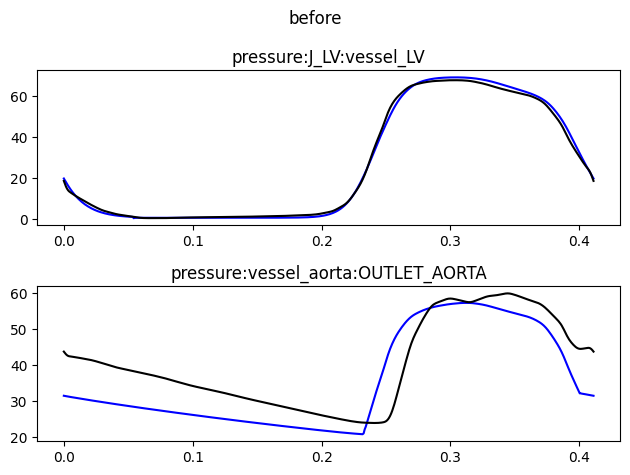

obj_val_1 =  0.035762442529711246


In [5]:
cycle_duration = 0.411
maxit = 10000000

fwd_sim_file = "config_preop_v1.json"

calibration_data_file = "calibration_preop_v1.json"

var_to_opt = ["pressure:J_LV:vessel_LV", "pressure:vessel_aorta:OUTLET_AORTA"]    
plot_vars = ["pressure:J_LV:vessel_LV", "pressure:vessel_aorta:OUTLET_AORTA"] 

targets_all = ['Emax', 'Emin', 't_shift', 'tau_1', 'tau_2', 'm1', 'm2', 'Rd', 'Rp', 'C']

bounds_all = {'Emax'    : [0.0, 5e4], 
              'Emin'    : [0.0, 1e4], 
              't_shift' : [0.0, 5*cycle_duration], 
              'tau_1'   : [0.0, 5*cycle_duration], 
              'tau_2'   : [0.0, 5*cycle_duration], 
              'm1'      : [0.0, 500.0], 
              'm2'      : [0.0, 500.0],
              'C'       : [0.0, 100],
              'Rd'      : [0.0, 3e4],
              'Rp'      : [0.0, 3e4]}

optimizer = optimizer_class(fwd_sim_file,calibration_data_file,var_to_opt,bounds_all,cycle_duration,maxit,plot_vars)

optimizer.run_and_update()

obj_val_1 = optimizer.objective_function()

optimizer.plot('before')

print("obj_val_1 = ", obj_val_1)

result =         message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.0005544599435809563
             x: [ 5.069e-02  1.904e-01  3.474e-01  1.902e+01  2.449e+01]
           nit: 234
          nfev: 417
 final_simplex: (array([[ 5.069e-02,  1.904e-01, ...,  1.902e+01,
                         2.449e+01],
                       [ 5.069e-02,  1.904e-01, ...,  1.902e+01,
                         2.449e+01],
                       ...,
                       [ 5.069e-02,  1.904e-01, ...,  1.902e+01,
                         2.449e+01],
                       [ 5.069e-02,  1.904e-01, ...,  1.902e+01,
                         2.449e+01]], shape=(6, 5)), array([ 5.545e-04,  5.545e-04,  5.545e-04,  5.545e-04,
                        5.545e-04,  5.545e-04]))
volume_lv_initial =  6.51417884869375
at t =  0.25071000000000065 , p_aorta_mmHg =  42.62224153623039
at t =  0.25071000000000065 , p_rpa_mmHg =  -4.8985082199753105e-17
at t =  0.250710000

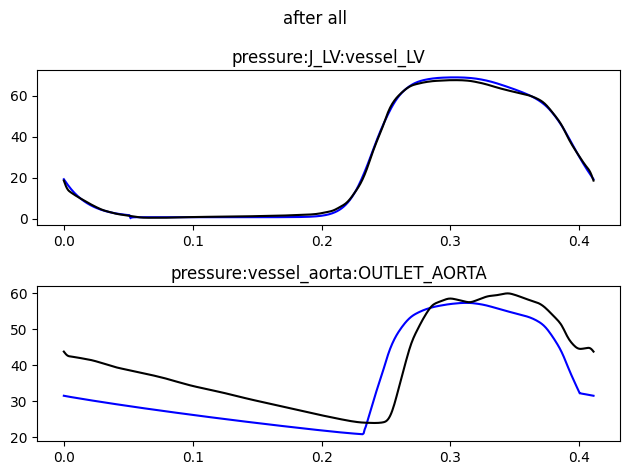

In [6]:
targets = ['t_shift', 'tau_1', 'tau_2', 'm1', 'm2']
optimizer.variables_to_opt = ["pressure:J_LV:vessel_LV"]

result = run_optimization(optimizer, targets)
print("result = ", result)
optimizer.print_summary(targets_all)
optimizer.plot('after all')

result =         message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.03596860860885914
             x: [ 1.298e-04]
           nit: 1
          nfev: 2
 final_simplex: (array([[ 1.298e-04],
                       [ 1.363e-04]]), array([ 3.597e-02,  3.598e-02]))
volume_lv_initial =  6.513514811724074
at t =  0.25071000000000065 , p_aorta_mmHg =  42.70717914284957
at t =  0.25071000000000065 , p_rpa_mmHg =  9.305533955910509e-17
at t =  0.25071000000000065 , p_lpa_mmHg =  9.305533955910509e-17
INFLOW_LV:
Emax =  13173.586506979238
INFLOW_LV:
Emin =  135.6730175691912
INFLOW_LV:
t_shift =  0.050690000888245865
INFLOW_LV:
tau_1 =  0.190421951688192
INFLOW_LV:
tau_2 =  0.3473641039436033
INFLOW_LV:
m1 =  19.02002926621376
INFLOW_LV:
m2 =  24.489476626807622
OUTLET_AORTA:
Rd =  18220.827340815835
OUTLET_RPA:
Rd =  9.38985736925515e-16
OUTLET_LPA:
Rd =  9.38985736925515e-16
OUTLET_AORTA:
Rp =  1183.9693715129288
OUTLET_RPA:
Rp =  6.101426307

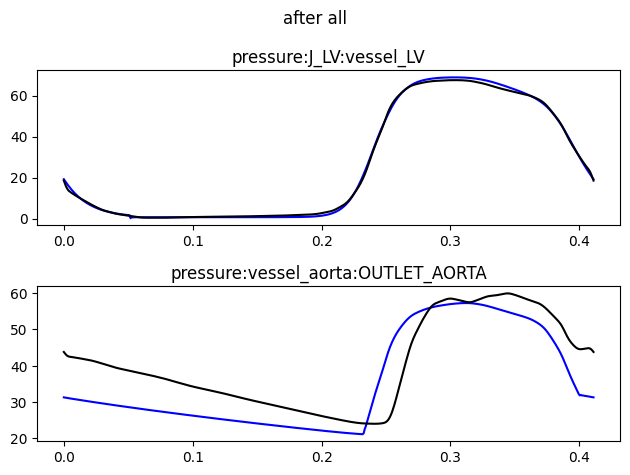

In [7]:
targets = ['C']
optimizer.variables_to_opt = ["pressure:vessel_aorta:OUTLET_AORTA"]

result = run_optimization(optimizer, targets)
print("result = ", result)
optimizer.print_summary(targets_all)
optimizer.plot('after all')

result =         message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.0005538126140641722
             x: [ 5.069e-02  1.904e-01  3.474e-01  1.904e+01  2.444e+01]
           nit: 241
          nfev: 400
 final_simplex: (array([[ 5.069e-02,  1.904e-01, ...,  1.904e+01,
                         2.444e+01],
                       [ 5.069e-02,  1.904e-01, ...,  1.904e+01,
                         2.444e+01],
                       ...,
                       [ 5.069e-02,  1.904e-01, ...,  1.904e+01,
                         2.444e+01],
                       [ 5.069e-02,  1.904e-01, ...,  1.904e+01,
                         2.444e+01]], shape=(6, 5)), array([ 5.538e-04,  5.538e-04,  5.538e-04,  5.538e-04,
                        5.538e-04,  5.538e-04]))
volume_lv_initial =  6.512245465462523
at t =  0.25071000000000065 , p_aorta_mmHg =  42.706317398481666
at t =  0.25071000000000065 , p_rpa_mmHg =  4.6537953060973404e-17
at t =  0.25071000

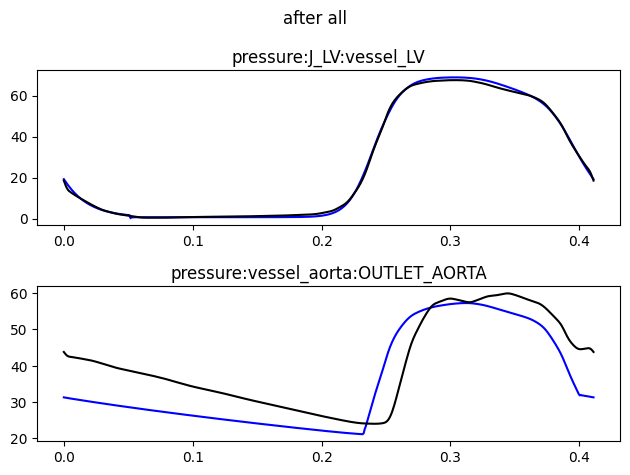

In [8]:
targets = ['t_shift', 'tau_1', 'tau_2', 'm1', 'm2']
optimizer.variables_to_opt = ["pressure:J_LV:vessel_LV"]

result = run_optimization(optimizer, targets)
print("result = ", result)
optimizer.print_summary(targets_all)
optimizer.plot('after all')

result =         message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.03653851967310519
             x: [ 1.363e-04]
           nit: 1
          nfev: 2
 final_simplex: (array([[ 1.363e-04],
                       [ 1.431e-04]]), array([ 3.654e-02,  3.659e-02]))
volume_lv_initial =  6.511603976506135
at t =  0.25071000000000065 , p_aorta_mmHg =  42.78815089160172
at t =  0.25071000000000065 , p_rpa_mmHg =  2.0989675366820182e-16
at t =  0.25071000000000065 , p_lpa_mmHg =  2.0989675366820182e-16
INFLOW_LV:
Emax =  13173.586506979238
INFLOW_LV:
Emin =  135.6730175691912
INFLOW_LV:
t_shift =  0.05069000023257074
INFLOW_LV:
tau_1 =  0.19041146372638718
INFLOW_LV:
tau_2 =  0.3473697336515519
INFLOW_LV:
m1 =  19.036538317450262
INFLOW_LV:
m2 =  24.44254017423924
OUTLET_AORTA:
Rd =  18220.827340815835
OUTLET_RPA:
Rd =  9.38985736925515e-16
OUTLET_LPA:
Rd =  9.38985736925515e-16
OUTLET_AORTA:
Rp =  1183.9693715129288
OUTLET_RPA:
Rp =  6.101426

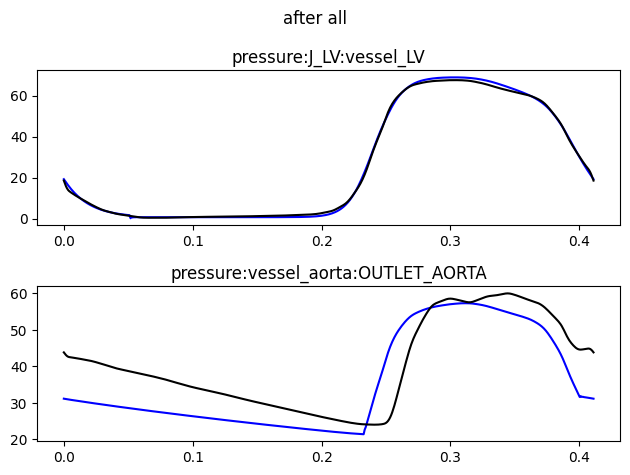

In [9]:
targets = ['C']
optimizer.variables_to_opt = ["pressure:J_LV:vessel_LV", "pressure:vessel_aorta:OUTLET_AORTA"]

result = run_optimization(optimizer, targets)
print("result = ", result)
optimizer.print_summary(targets_all)
optimizer.plot('after all')

result =         message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.035817206133853634
             x: [ 5.069e-02  1.894e-01  3.543e-01  1.826e+01  3.132e+01]
           nit: 351
          nfev: 589
 final_simplex: (array([[ 5.069e-02,  1.894e-01, ...,  1.826e+01,
                         3.132e+01],
                       [ 5.069e-02,  1.894e-01, ...,  1.826e+01,
                         3.132e+01],
                       ...,
                       [ 5.069e-02,  1.894e-01, ...,  1.826e+01,
                         3.132e+01],
                       [ 5.069e-02,  1.894e-01, ...,  1.826e+01,
                         3.132e+01]], shape=(6, 5)), array([ 3.582e-02,  3.582e-02,  3.582e-02,  3.582e-02,
                        3.582e-02,  3.582e-02]))
volume_lv_initial =  5.226113914085448
at t =  0.25071000000000065 , p_aorta_mmHg =  42.255505964485565
at t =  0.25071000000000065 , p_rpa_mmHg =  7.157318103008629e-17
at t =  0.2507100000

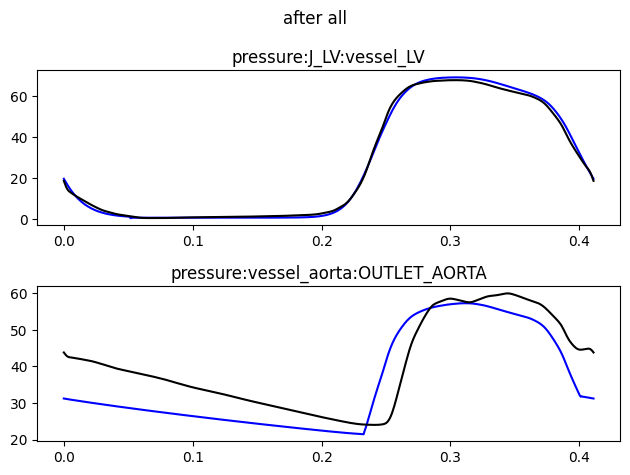

In [10]:
targets = ['t_shift', 'tau_1', 'tau_2', 'm1', 'm2']
optimizer.variables_to_opt = ["pressure:J_LV:vessel_LV", "pressure:vessel_aorta:OUTLET_AORTA"]

result = run_optimization(optimizer, targets)
print("result = ", result)
optimizer.print_summary(targets_all)
optimizer.plot('after all')

result =         message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.035810961615558315
             x: [ 1.267e+04  1.404e+02]
           nit: 55
          nfev: 113
 final_simplex: (array([[ 1.267e+04,  1.404e+02],
                       [ 1.267e+04,  1.404e+02],
                       [ 1.267e+04,  1.404e+02]]), array([ 3.581e-02,  3.581e-02,  3.581e-02]))
volume_lv_initial =  5.442522442523574
at t =  0.25071000000000065 , p_aorta_mmHg =  42.191700654197554
at t =  0.25071000000000065 , p_rpa_mmHg =  2.1341427950608373e-16
at t =  0.25071000000000065 , p_lpa_mmHg =  2.1341427950608373e-16
INFLOW_LV:
Emax =  12667.322898736034
INFLOW_LV:
Emin =  140.44585898262426
INFLOW_LV:
t_shift =  0.050690005643485476
INFLOW_LV:
tau_1 =  0.18939919642752506
INFLOW_LV:
tau_2 =  0.3542802482730453
INFLOW_LV:
m1 =  18.25804089495962
INFLOW_LV:
m2 =  31.316768151285913
OUTLET_AORTA:
Rd =  18220.827340815835
OUTLET_RPA:
Rd =  9.38985736925515e-16
O

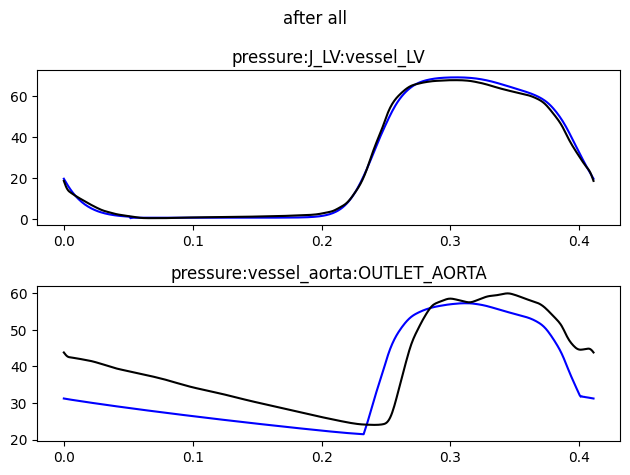

In [11]:
targets = ['Emax', 'Emin']
optimizer.variables_to_opt = ["pressure:J_LV:vessel_LV", "pressure:vessel_aorta:OUTLET_AORTA"]

result = run_optimization(optimizer, targets)
print("result = ", result)
optimizer.print_summary(targets_all)
optimizer.plot('after all')

result =         message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.004454285386859507
             x: [ 2.717e+02  2.698e+04  7.557e-05]
           nit: 152
          nfev: 283
 final_simplex: (array([[ 2.717e+02,  2.698e+04,  7.557e-05],
                       [ 2.717e+02,  2.698e+04,  7.557e-05],
                       [ 2.717e+02,  2.698e+04,  7.557e-05],
                       [ 2.717e+02,  2.698e+04,  7.557e-05]]), array([ 4.454e-03,  4.454e-03,  4.454e-03,  4.454e-03]))
volume_lv_initial =  5.4664128343075244
at t =  0.25071000000000065 , p_aorta_mmHg =  34.71453315408318
at t =  0.25071000000000065 , p_rpa_mmHg =  2.601536443794772e-16
at t =  0.25071000000000065 , p_lpa_mmHg =  2.601536443794772e-16
INFLOW_LV:
Emax =  12667.322898736034
INFLOW_LV:
Emin =  140.44585898262426
INFLOW_LV:
t_shift =  0.050690005643485476
INFLOW_LV:
tau_1 =  0.18939919642752506
INFLOW_LV:
tau_2 =  0.3542802482730453
INFLOW_LV:
m1 =  18.25804089495

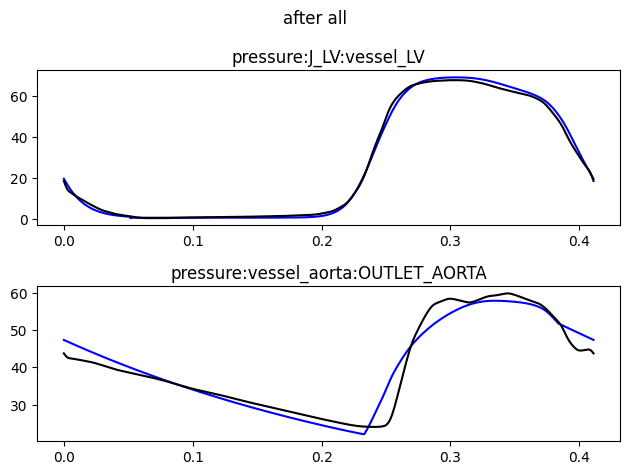

In [12]:
targets = ['Rp', 'Rd', 'C']
optimizer.variables_to_opt = ["pressure:vessel_aorta:OUTLET_AORTA"]

result = run_optimization(optimizer, targets)
print("result = ", result)
optimizer.print_summary(targets_all)
optimizer.plot('after all')

result =         message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.00028504923948214137
             x: [ 6.599e+02  4.998e+04  4.822e-02  1.966e-01  3.467e-01
                  1.791e+01  2.425e+01]
           nit: 2397
          nfev: 3611
 final_simplex: (array([[ 6.599e+02,  4.998e+04, ...,  1.791e+01,
                         2.425e+01],
                       [ 6.599e+02,  4.998e+04, ...,  1.791e+01,
                         2.425e+01],
                       ...,
                       [ 6.599e+02,  4.998e+04, ...,  1.791e+01,
                         2.425e+01],
                       [ 6.599e+02,  4.998e+04, ...,  1.791e+01,
                         2.425e+01]], shape=(8, 7)), array([ 2.850e-04,  2.850e-04,  2.850e-04,  2.850e-04,
                        2.850e-04,  2.850e-04,  2.850e-04,  2.850e-04]))
volume_lv_initial =  1.9615697135182992
at t =  0.25071000000000065 , p_aorta_mmHg =  35.048691413113964
at t =  0.25071000

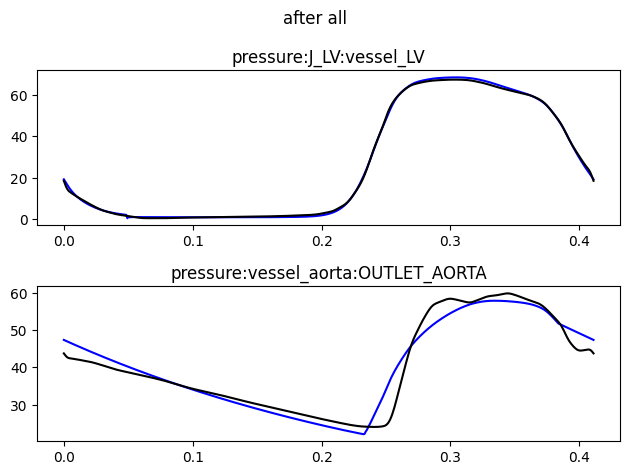

In [13]:
targets = ['Emin', 'Emax', 't_shift', 'tau_1', 'tau_2', 'm1', 'm2']
optimizer.variables_to_opt = ["pressure:J_LV:vessel_LV"]

result = run_optimization(optimizer, targets)
print("result = ", result)
optimizer.print_summary(targets_all)
optimizer.plot('after all')

result =         message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.0044608606898719795
             x: [ 2.233e+02  2.605e+04  7.500e-05]
           nit: 139
          nfev: 263
 final_simplex: (array([[ 2.233e+02,  2.605e+04,  7.500e-05],
                       [ 2.233e+02,  2.605e+04,  7.500e-05],
                       [ 2.233e+02,  2.605e+04,  7.500e-05],
                       [ 2.233e+02,  2.605e+04,  7.500e-05]]), array([ 4.461e-03,  4.461e-03,  4.461e-03,  4.461e-03]))
volume_lv_initial =  1.9615950683031522
at t =  0.25071000000000065 , p_aorta_mmHg =  34.07567574737631
at t =  0.25071000000000065 , p_rpa_mmHg =  1.4639946626343523e-16
at t =  0.25071000000000065 , p_lpa_mmHg =  1.4639946626343523e-16
INFLOW_LV:
Emax =  49984.84501195399
INFLOW_LV:
Emin =  659.925263608052
INFLOW_LV:
t_shift =  0.04822400002069671
INFLOW_LV:
tau_1 =  0.19658146781355335
INFLOW_LV:
tau_2 =  0.346721196035067
INFLOW_LV:
m1 =  17.9073810094296

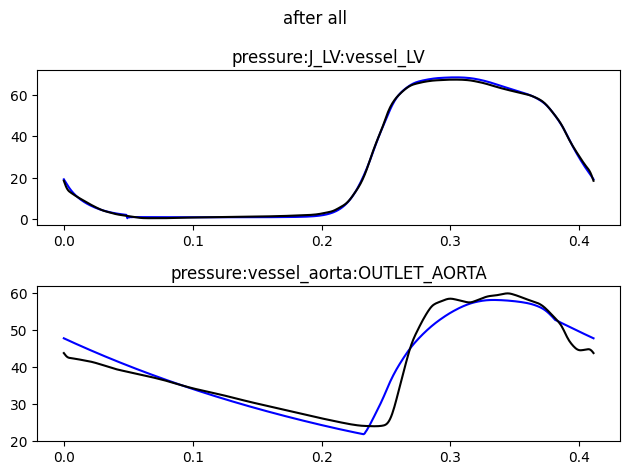

In [14]:
targets = ['Rp', 'Rd', 'C']
optimizer.variables_to_opt = ["pressure:vessel_aorta:OUTLET_AORTA"]

result = run_optimization(optimizer, targets)
print("result = ", result)
optimizer.print_summary(targets_all)
optimizer.plot('after all')

result =         message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.0047283602568773805
             x: [ 6.696e+02  4.990e+04  4.822e-02  1.966e-01  3.445e-01
                  1.713e+01  2.300e+01  2.258e+02  2.588e+04  7.542e-05]
           nit: 2297
          nfev: 3352
 final_simplex: (array([[ 6.696e+02,  4.990e+04, ...,  2.588e+04,
                         7.542e-05],
                       [ 6.696e+02,  4.990e+04, ...,  2.588e+04,
                         7.542e-05],
                       ...,
                       [ 6.696e+02,  4.990e+04, ...,  2.588e+04,
                         7.542e-05],
                       [ 6.696e+02,  4.990e+04, ...,  2.588e+04,
                         7.542e-05]], shape=(11, 10)), array([ 4.728e-03,  4.728e-03,  4.728e-03,  4.728e-03,
                        4.728e-03,  4.728e-03,  4.728e-03,  4.728e-03,
                        4.728e-03,  4.728e-03,  4.728e-03]))
volume_lv_initial =  2.0984338

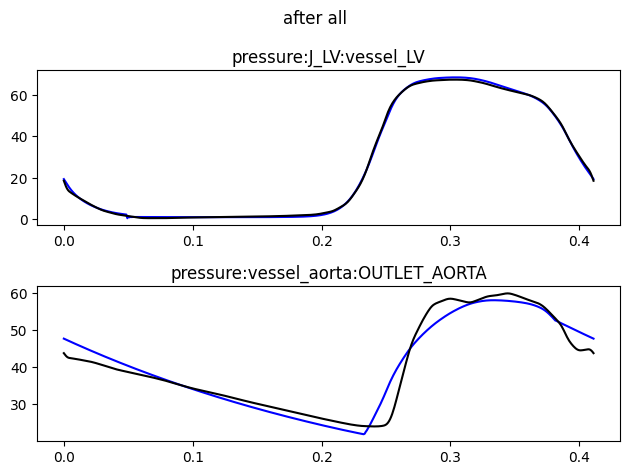

In [15]:
targets = ['Emin', 'Emax', 't_shift', 'tau_1', 'tau_2', 'm1', 'm2', 'Rp', 'Rd', 'C']
optimizer.variables_to_opt = ["pressure:J_LV:vessel_LV", "pressure:vessel_aorta:OUTLET_AORTA"]

result = run_optimization(optimizer, targets)
print("result = ", result)
optimizer.print_summary(targets_all)
optimizer.plot('after all')